# Extracción de Variable Objetivo y Merge con Preoperatorio

Este notebook extrae la variable objetivo (target) del dataset postoperatorio y luego une los resultados con el dataset preoperatorio, generando los datasets mergeados por versión.

## Estructura

1. Base de librerías
2. Lectura de datos
3. Pipeline de extracción de target
4. Merge multi-versión (Target + Preoperatorio)
5. Resultados y análisis de flags


## 1. Base de Librerías


In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from utils.target_extraction import run_target_extraction_pipeline
from utils.multi_version import run_merge_pipeline
from utils.version_config import (
    ACTIVE_VERSIONS,
    VERSION_HISTORY,
    get_recommended_experimental_versions,
    get_active_target_export_names,
    build_target_versions_config,
)


## 2. Lectura de Datos


In [2]:
# Cargar datasets
df_postqx = pd.read_excel('../data/OPERA POSTQX.xlsx')

print(f"Postoperatorio: {df_postqx.shape[0]:,} filas × {df_postqx.shape[1]} columnas")


Postoperatorio: 29,865 filas × 76 columnas


## 3. Pipeline de Extracción


In [3]:
versions = get_recommended_experimental_versions()

print(f"Versiones activas: {ACTIVE_VERSIONS}")
print("Historial de versiones ejecutadas:")
display(pd.DataFrame(VERSION_HISTORY))

print("Configuración de versiones a ejecutar:")
display(pd.DataFrame(versions)[["name", "threshold", "flags_to_use", "description", "export_name"]])

df, df_versions = run_target_extraction_pipeline(
    df_postqx=df_postqx,
    versions=versions,
    umbral_estancia=3,
    export_dir="../data",
    export=True,
)

df_v1 = df_versions.get("v1")
df_v2 = df_versions.get("v2")

Versiones activas: ['target_a_sensible', 'target_b_clinicamente_relevante', 'target_c_alta_severidad', 'target_d_eventos_adversos', 'target_e_alta_senal']
Historial de versiones ejecutadas:


,version,threshold,flags_to_use,apply_cancel_non_medico_rule,export_name,description,executed_on,notes
0,v1,1,"[flag_cancelacion, flag_reservas, flag_fisiolo...",True,OPERA_POS_v1.xlsx,Baseline completo con TODAS las flags (>=1 flag),2026-02-28,Baseline histórico completo
1,v2,2,"[flag_cancelacion, flag_reservas, flag_fisiolo...",True,OPERA_POS_v2.xlsx,Con agregación (>=2 flags),2026-02-28,Baseline histórico
2,v3_sin_liquidos,1,"[flag_cancelacion, flag_via_aerea, flag_desenl...",True,OPERA_POS_v3_sin_liquidos.xlsx,Sin flag_liquidos (>=1 flag),2026-02-28,Sensibilidad clínica


Configuración de versiones a ejecutar:


,name,threshold,flags_to_use,description,export_name
0,target_a_sensible,1,"[flag_cancelacion, flag_reservas, flag_fisiolo...","Target A - Sensible: flags relevantes, thresho...",OPERA_POS_target_a_sensible.xlsx
1,target_b_clinicamente_relevante,1,"[flag_cancelacion, flag_reservas, flag_via_aer...",Target B - Clínicamente Relevante: flags preop...,OPERA_POS_target_b_clinicamente_relevante.xlsx
2,target_c_alta_severidad,2,"[flag_cancelacion, flag_reservas, flag_via_aer...","Target C - Alta Severidad: mismas flags que B,...",OPERA_POS_target_c_alta_severidad.xlsx
3,target_d_eventos_adversos,1,"[flag_cancelacion, flag_via_aerea, flag_liquid...",Target D - Eventos Adversos: flags refinadas c...,OPERA_POS_target_d_eventos_adversos.xlsx
4,target_e_alta_senal,1,"[flag_estancia, flag_tecnica, flag_tiempos, fl...",Target E - Señal Alta: solo flags con MI>0.01 ...,OPERA_POS_target_e_alta_senal.xlsx


INICIANDO PIPELINE DE EXTRACCIÓN

VALIDACIÓN CANCELACION:
  Canceladas por medico: 12 (0.04%)

VALIDACIÓN RESERVAS:
  flag_reserva_hemoderivados: 247 casos (0.83%)
  flag_reserva_sangre: 243 casos (0.81%)

  TOTAL flag_reservas: 437 (1.46%)

VALIDACIÓN VARIABLES FISIOLÓGICAS (VALORES ANORMALES):
  (Valores inválidos imputados con valores normales antes de evaluar)
  flag_presion_sistolica_anormal: 1,155 casos (3.87%)
  flag_presion_diastolica_anormal: 684 casos (2.29%)
  flag_presion_media_anormal: 401 casos (1.34%)
  flag_frecuencia_cardiaca_anormal: 913 casos (3.06%)
  flag_saturacion_oxigeno_anormal: 900 casos (3.01%)
  flag_temperatura_anormal: 790 casos (2.65%)
  flag_glucometria_anormal: 973 casos (3.26%)

  TOTAL flag_fisiologicas: 4,710 (15.77%)

VALIDACIÓN TIEMPOS (DURACIONES LARGAS):
  Percentil 90 cirujano: 140.0 minutos
  Percentil 90 anestesia: 168.3 minutos
  flag_duracion_cirujano_larga: 2,279 casos (7.63%)
  flag_duracion_anestesia_larga: 1,597 casos (5.35%)

  TOTAL fl

## 4. Merge Multi-Versión de Target + Preoperatorio

Une automáticamente el dataset preoperatorio con **todas** las versiones de target generadas (`OPERA_POS_*.xlsx`).


In [4]:
DATA_DIR = Path("../data")
MERGED_DIR = DATA_DIR / "merged_versions"
MERGED_DIR.mkdir(parents=True, exist_ok=True)

active_target_files = get_active_target_export_names()

print(f"Versiones activas: {ACTIVE_VERSIONS}")
display(pd.DataFrame(VERSION_HISTORY))

merge_artifacts = run_merge_pipeline(
    data_dir=DATA_DIR,
    merged_dir=MERGED_DIR,
    active_target_files=active_target_files,
)

print("Dataset Preoperatorio:")
print(f"  Ruta: {merge_artifacts['preop_path']}")
print(
    f"  Filas: {merge_artifacts['preop_shape'][0]:,} × "
    f"Columnas: {merge_artifacts['preop_shape'][1]}"
)


Versiones activas: ['target_a_sensible', 'target_b_clinicamente_relevante', 'target_c_alta_severidad', 'target_d_eventos_adversos', 'target_e_alta_senal']


,version,threshold,flags_to_use,apply_cancel_non_medico_rule,export_name,description,executed_on,notes
0,v1,1,"[flag_cancelacion, flag_reservas, flag_fisiolo...",True,OPERA_POS_v1.xlsx,Baseline completo con TODAS las flags (>=1 flag),2026-02-28,Baseline histórico completo
1,v2,2,"[flag_cancelacion, flag_reservas, flag_fisiolo...",True,OPERA_POS_v2.xlsx,Con agregación (>=2 flags),2026-02-28,Baseline histórico
2,v3_sin_liquidos,1,"[flag_cancelacion, flag_via_aerea, flag_desenl...",True,OPERA_POS_v3_sin_liquidos.xlsx,Sin flag_liquidos (>=1 flag),2026-02-28,Sensibilidad clínica


Dataset Preoperatorio:
  Ruta: ../data/OPERA_PRE.xlsx
  Filas: 30,962 × Columnas: 236


In [5]:
print(f"Versiones target detectadas (activas): {len(merge_artifacts['target_files'])}")
for path in merge_artifacts["target_files"]:
    print(f"  - {Path(path).name}")

if merge_artifacts.get("ignored_target_files"):
    print("\nArchivos target ignorados (no activos):")
    for name in merge_artifacts["ignored_target_files"]:
        print(f"  - {name}")


Versiones target detectadas (activas): 5
  - OPERA_POS_target_a_sensible.xlsx
  - OPERA_POS_target_b_clinicamente_relevante.xlsx
  - OPERA_POS_target_c_alta_severidad.xlsx
  - OPERA_POS_target_d_eventos_adversos.xlsx
  - OPERA_POS_target_e_alta_senal.xlsx

Archivos target ignorados (no activos):
  - OPERA_POS.xlsx
  - OPERA_POS_v1.xlsx
  - OPERA_POS_v2.xlsx
  - OPERA_POS_v3_sin_liquidos.xlsx
  - OPERA_POS_v4_preop_focus.xlsx
  - OPERA_POS_v5_preop_focus_agregado.xlsx
  - OPERA_POS_v6_preop_strict.xlsx


### Merge por Versión


In [6]:
merged_by_version = merge_artifacts["merged_by_version"]
df_merge_summary = merge_artifacts["merge_summary"]
df_merge_summary


,version,target_file,rows,cols,target_0,target_1,target_1_pct
0,target_a_sensible,OPERA_POS_target_a_sensible.xlsx,29865,237,9512,20353,68.15
1,target_b_clinicamente_relevante,OPERA_POS_target_b_clinicamente_relevante.xlsx,29865,237,12700,17165,57.48
2,target_c_alta_severidad,OPERA_POS_target_c_alta_severidad.xlsx,29865,237,24033,5832,19.53
3,target_d_eventos_adversos,OPERA_POS_target_d_eventos_adversos.xlsx,29865,237,19557,10308,34.52
4,target_e_alta_senal,OPERA_POS_target_e_alta_senal.xlsx,29865,237,12621,17244,57.74


In [7]:
first_version = df_merge_summary.iloc[0]["version"]
print(f"Primera versión detectada: {first_version}")
merged_by_version[first_version].head(3)


Primera versión detectada: target_a_sensible


,Documento PMD,Edad,Peso (Kg),Talla (cm),IMC,Antecedentes anestésicos,Tensión Arterial Sistólica (mm/Hg),Tensión Arterial Diastólica (mm/Hg),Tensión Arterial Media (mm/Hg),Frecuencia Respiratoria,Temperatura,Puntaje Mallampati,anio,mes,dia_semana,Hora_decimal,Sexo_encoded,Atención_encoded,Grupo Sanguíneo_A,Grupo Sanguíneo_AB,Grupo Sanguíneo_B,Grupo Sanguíneo_O,Grupo Sanguíneo_Sin Dato,RH_Negativo,RH_Positivo,RH_Sin Dato,Antecedente neurológicos_convulsiones,Antecedente neurológicos_negativo,Antecedente neurológicos_neoplasia,Antecedente neurológicos_neuropatia,Antecedente neurológicos_tce,Antecedente neurológicos_trastorno psiquiatrico,Antecedente respiratorios_asma,Antecedente respiratorios_epoc,Antecedente respiratorios_negativo,Antecedente respiratorios_negativoneumonia,Antecedente respiratorios_neumonia,Antecedentes cardiovasculares_angina,Antecedentes cardiovasculares_arritmias,Antecedentes cardiovasculares_cardiopatias,Antecedentes cardiovasculares_hta,Antecedentes cardiovasculares_icc,Antecedentes cardiovasculares_infarto,Antecedentes cardiovasculares_negativo,Antecedentes cardiovasculares_valvulopatia,Antecedente hematológicos _anemia,Antecedente hematológicos _anticoagulantes,Antecedente hematológicos _aspirina,Antecedente hematológicos _discrasias,Antecedente hematológicos _negativo,Antecedente hematológicos _plavix,Antecedente hematológicos _transfusiones,Antecedente endocrinológicos_diabetes,Antecedente endocrinológicos_negativo,Antecedente endocrinológicos_obesidad,Antecedente endocrinológicos_tiroides,Antecedente renales_falla renal,Antecedente renales_infeccion urinaria,Antecedente renales_litiasis,Antecedente renales_negativo,Antecedente gastrointestinales_falla hepatica,Antecedente gastrointestinales_gastritis,Antecedente gastrointestinales_negativo,Antecedente gastrointestinales_rge,Anestesia previa_bag,Anestesia previa_bloqueo,Anestesia previa_conductiva,Anestesia previa_desconocido,Anestesia previa_epidural,Anestesia previa_espinal,Anestesia previa_general,Anestesia previa_intraarticular,Anestesia previa_local,Anestesia previa_neuroaxial,Anestesia previa_peribulbar,Anestesia previa_peridural,Anestesia previa_raquidea,Anestesia previa_regional,Anestesia previa_sedacion,Anestesia previa_topica,Examen_Hemoglobina(g/dl),Examen_PT (INR),Examen_Glicemia (mg/dl),Examen_Hematocrito (%),Examen_Plaquetas (ml),Examen_Leucocitos (ml),Examen_PTT,Examen_K (meq/L),Examen_Na (meq/L),Examen_P de O,Cuello Móvil_encoded,Apertura Oral_encoded,Estado Nutricional_encoded,Color de Piel_cianosis,Color de Piel_ictericia,Color de Piel_normal,Color de Piel_palidez,Sistema Nervioso_Sin dato,Sistema Nervioso_agitado,Sistema Nervioso_normal,Sistema Nervioso_par craneal anormal,Sistema Nervioso_sedado,Apertura Visual_encoded,Respuesta Verbal_encoded,Respuesta Motora_encoded,Sistema Respiratorio_auscultacion anormal,Sistema Respiratorio_disnea,Sistema Respiratorio_normal,Sistema Respiratorio_otro,Sistema cardiovascular_galope,Sistema cardiovascular_ingurgitacion yugular,Sistema cardiovascular_normal,Sistema cardiovascular_otro,Sistema cardiovascular_pulso anormal,Sistema cardiovascular_soplo,Abdomen_distension,Abdomen_masas,Abdomen_normal,Abdomen_otro,Arritmia_encoded,Disnea_encoded,Angina_encoded,Condición_alcohol,Condición_embarazo actual,Condición_farmacodependencia,Condición_fumador,Condición_hepatitis b,Condición_hipertermia maligna,Condición_ninguna,Condición_testigo jehova,Condición_vih,Tipo de anestesia propuesta_bloqueo iv,Tipo de anestesia propuesta_bloqueo n,Tipo de anestesia propuesta_general,Tipo de anestesia propuesta_local,Tipo de anestesia propuesta_peridural,Tipo de anestesia propuesta_raquidea,Tipo de anestesia propuesta_sedacion,Tipo de anestesia propuesta_sin dato,Prótesis Dental_fija,Prótesis Dental_movil,Prótesis Dental_no,Alérgeno_alimentos,Alérgeno_ambiental_animales,Alérgeno_contacto_hospitalario,Alérgeno_med_alergias_respiratorio,Alérgeno_med_analgesia_no_opioide,Alérgeno_med_anestesia_y_relajantes,Alérgeno_med_a

### Resumen Comparativo entre Versiones


In [8]:
print("=" * 90)
print("RESUMEN MERGE PREOP + TARGET (MULTI-VERSIÓN)")
print("=" * 90)
print(df_merge_summary.to_string(index=False))


RESUMEN MERGE PREOP + TARGET (MULTI-VERSIÓN)
                        version                                    target_file  rows  cols  target_0  target_1  target_1_pct
              target_a_sensible               OPERA_POS_target_a_sensible.xlsx 29865   237      9512     20353         68.15
target_b_clinicamente_relevante OPERA_POS_target_b_clinicamente_relevante.xlsx 29865   237     12700     17165         57.48
        target_c_alta_severidad         OPERA_POS_target_c_alta_severidad.xlsx 29865   237     24033      5832         19.53
      target_d_eventos_adversos       OPERA_POS_target_d_eventos_adversos.xlsx 29865   237     19557     10308         34.52
            target_e_alta_senal             OPERA_POS_target_e_alta_senal.xlsx 29865   237     12621     17244         57.74


In [9]:
target_distribution = (
    df_merge_summary[["version", "target_0", "target_1", "target_1_pct"]]
    .sort_values("target_1_pct", ascending=False)
    .reset_index(drop=True)
)
target_distribution


,version,target_0,target_1,target_1_pct
0,target_a_sensible,9512,20353,68.15
1,target_e_alta_senal,12621,17244,57.74
2,target_b_clinicamente_relevante,12700,17165,57.48
3,target_d_eventos_adversos,19557,10308,34.52
4,target_c_alta_severidad,24033,5832,19.53


### Exportación de Datasets Mergeados


In [10]:
df_exports = merge_artifacts["exports"]
df_exports


,version,path,rows
0,target_a_sensible,../data/merged_versions/OPERA_COMPLETO_target_...,29865
1,target_b_clinicamente_relevante,../data/merged_versions/OPERA_COMPLETO_target_...,29865
2,target_c_alta_severidad,../data/merged_versions/OPERA_COMPLETO_target_...,29865
3,target_d_eventos_adversos,../data/merged_versions/OPERA_COMPLETO_target_...,29865
4,target_e_alta_senal,../data/merged_versions/OPERA_COMPLETO_target_...,29865


In [11]:
print("=" * 90)
print("EXPORTACIÓN COMPLETADA")
print("=" * 90)
print(f"Resumen de merge: {merge_artifacts['summary_path']}")
print(f"Inventario de exports: {merge_artifacts['exports_path']}")
print("\nDatasets exportados:")
for _, row in df_exports.iterrows():
    print(f"  - [{row['version']}] {row['path']} ({row['rows']:,} filas)")


EXPORTACIÓN COMPLETADA
Resumen de merge: ../data/merged_versions/merge_summary_versions.csv
Inventario de exports: ../data/merged_versions/merged_exports_versions.csv

Datasets exportados:
  - [target_a_sensible] ../data/merged_versions/OPERA_COMPLETO_target_a_sensible.xlsx (29,865 filas)
  - [target_b_clinicamente_relevante] ../data/merged_versions/OPERA_COMPLETO_target_b_clinicamente_relevante.xlsx (29,865 filas)
  - [target_c_alta_severidad] ../data/merged_versions/OPERA_COMPLETO_target_c_alta_severidad.xlsx (29,865 filas)
  - [target_d_eventos_adversos] ../data/merged_versions/OPERA_COMPLETO_target_d_eventos_adversos.xlsx (29,865 filas)
  - [target_e_alta_senal] ../data/merged_versions/OPERA_COMPLETO_target_e_alta_senal.xlsx (29,865 filas)


## 5. Resultados y Análisis de Flags


### Utils

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Optional, List

def plot_correlation_heatmap_flags(
    df: pd.DataFrame,
    flags: Optional[List[str]] = None,
    figsize: tuple = (14, 12),
    cmap: str = 'coolwarm',
    annot: bool = True,
    fmt: str = '.2f',
    vmin: float = -1.0,
    vmax: float = 1.0,
    title: str = 'Matriz de Correlación entre Flags de Validación',
    save_path: Optional[str] = None,
    dpi: int = 300
) -> pd.DataFrame:
    """
    Genera un heatmap de correlación entre los flags de validación.
    
    Parámetros:
        df: DataFrame con los flags calculados
        flags: Lista de flags a incluir. Si None, usa todos los flags agregados.
        figsize: Tamaño de la figura (ancho, alto)
        cmap: Mapa de colores para el heatmap ('coolwarm', 'RdBu', 'viridis', etc.)
        annot: Si True, muestra los valores de correlación en cada celda
        fmt: Formato de los valores anotados ('.2f' para 2 decimales)
        vmin: Valor mínimo para el mapa de colores
        vmax: Valor máximo para el mapa de colores
        title: Título del gráfico
        save_path: Ruta para guardar la imagen (ej: 'correlacion_flags.png'). Si None, no guarda
        dpi: Resolución para guardar la imagen
    
    Retorna:
        DataFrame con la matriz de correlación
    """
    
    # Si no se especifican flags, usar todos los flags agregados disponibles
    if flags is None:
        flags = [
            'flag_cancelacion',
            'flag_reservas',
            'flag_fisiologicas',
            'flag_tiempos',
            'flag_induccion',
            'flag_via_aerea',
            'flag_ventilacion',
            'flag_tecnica',
            'flag_liquidos',
            'flag_desenlace',
            'flag_complicaciones_medicas',
            'flag_estancia',
            'flag_seguimiento'
        ]
    
    # Filtrar solo los flags que existen en el DataFrame
    flags_disponibles = [f for f in flags if f in df.columns]
    
    if not flags_disponibles:
        raise ValueError("No se encontraron flags en el DataFrame")
    
    if len(flags_disponibles) != len(flags):
        faltantes = set(flags) - set(flags_disponibles)
        print(f"⚠️  Advertencia: Los siguientes flags no se encontraron: {faltantes}")
    
    # Seleccionar solo las columnas de flags
    df_flags = df[flags_disponibles].copy()
    
    # Calcular matriz de correlación
    corr_matrix = df_flags.corr()
    
    # Crear nombres más legibles para el gráfico
    nombres_legibles = {
        'flag_cancelacion': 'Cancelación',
        'flag_reservas': 'Reservas',
        'flag_fisiologicas': 'Variables Fisiológicas',
        'flag_tiempos': 'Tiempos',
        'flag_induccion': 'Inducción',
        'flag_via_aerea': 'Vía Aérea',
        'flag_ventilacion': 'Ventilación',
        'flag_tecnica': 'Técnica Anestésica',
        'flag_liquidos': 'Líquidos',
        'flag_desenlace': 'Desenlace',
        'flag_complicaciones_medicas': 'Complicaciones Médicas',
        'flag_estancia': 'Estancia',
        'flag_seguimiento': 'Seguimiento'
    }
    
    # Crear matriz con nombres legibles
    corr_matrix_renamed = corr_matrix.copy()
    corr_matrix_renamed.index = [nombres_legibles.get(col, col) for col in corr_matrix_renamed.index]
    corr_matrix_renamed.columns = [nombres_legibles.get(col, col) for col in corr_matrix_renamed.columns]
    
    # Crear figura
    plt.figure(figsize=figsize)
    
    # Generar máscara para el triángulo superior (opcional, para mostrar solo triángulo inferior)
    mask = None  # Si quieres solo triángulo inferior, usa: mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    # Crear heatmap
    sns.heatmap(
        corr_matrix_renamed,
        annot=annot,
        fmt=fmt,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        center=0,
        square=True,
        linewidths=1,
        cbar_kws={"shrink": 0.8, "label": "Coeficiente de Correlación"},
        mask=mask,
        xticklabels=True,
        yticklabels=True
    )
    
    # Configurar título y etiquetas
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('', fontsize=12)
    plt.ylabel('', fontsize=12)
    
    # Rotar etiquetas si es necesario
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    # Ajustar layout
    plt.tight_layout()
    
    # Guardar si se especifica ruta
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"✓ Gráfico guardado en: {save_path}")
    
    plt.show()
    
    # Retornar matriz de correlación original (con nombres de columnas originales)
    return corr_matrix


# Función adicional para identificar correlaciones fuertes
def identificar_correlaciones_fuertes(
    corr_matrix: pd.DataFrame,
    umbral: float = 0.3,
    excluir_diagonal: bool = True
) -> pd.DataFrame:
    """
    Identifica pares de flags con correlaciones fuertes (por encima del umbral).
    
    Parámetros:
        corr_matrix: Matriz de correlación (retornada por plot_correlation_heatmap_flags)
        umbral: Umbral mínimo de correlación absoluta para considerar "fuerte"
        excluir_diagonal: Si True, excluye la diagonal (correlación consigo mismo = 1.0)
    
    Retorna:
        DataFrame con pares de flags y sus correlaciones
    """
    # Crear copia de la matriz
    corr_copy = corr_matrix.copy()
    
    # Excluir diagonal si se solicita
    if excluir_diagonal:
        np.fill_diagonal(corr_copy.values, np.nan)
    
    # Encontrar pares con correlación fuerte
    pares_fuertes = []
    
    for i in range(len(corr_copy.columns)):
        for j in range(len(corr_copy.columns)):
            if i != j or not excluir_diagonal:
                valor = corr_copy.iloc[i, j]
                if not np.isnan(valor) and abs(valor) >= umbral:
                    pares_fuertes.append({
                        'Flag 1': corr_copy.columns[i],
                        'Flag 2': corr_copy.columns[j],
                        'Correlación': valor,
                        'Tipo': 'Positiva' if valor > 0 else 'Negativa',
                        'Fuerza': 'Fuerte' if abs(valor) >= 0.7 else 'Moderada' if abs(valor) >= 0.5 else 'Débil'
                    })
    
    df_pares = pd.DataFrame(pares_fuertes)
    
    # Eliminar duplicados (A-B es igual a B-A)
    if len(df_pares) > 0:
        df_pares = df_pares[df_pares['Flag 1'] < df_pares['Flag 2']].copy()
        df_pares = df_pares.sort_values('Correlación', key=abs, ascending=False)
    
    return df_pares

In [13]:
def crear_tabla_resumen_ejecutiva(df: pd.DataFrame):
    """
    Crea una tabla resumen con estadísticas clave de cada categoría.
    """
    flags = {
        'flag_cancelacion': 'Cancelación',
        'flag_reservas': 'Reservas',
        'flag_fisiologicas': 'Variables Fisiológicas',
        'flag_tiempos': 'Tiempos',
        'flag_induccion': 'Inducción',
        'flag_via_aerea': 'Vía Aérea',
        'flag_ventilacion': 'Ventilación',
        'flag_tecnica': 'Técnica Anestésica',
        'flag_liquidos': 'Líquidos',
        'flag_desenlace': 'Desenlace',
        'flag_complicaciones_medicas': 'Complicaciones Médicas',
        'flag_estancia': 'Estancia',
        'flag_seguimiento': 'Seguimiento'
    }
    
    resumen = []
    
    for flag, nombre in flags.items():
        if flag in df.columns:
            total_casos = df[flag].sum()
            porcentaje = (total_casos / len(df)) * 100
            
            # Casos que tienen este flag Y target=1
            casos_con_target1 = ((df[flag] == 1) & (df['target'] == 1)).sum()
            porcentaje_target1 = (casos_con_target1 / total_casos * 100) if total_casos > 0 else 0
            
            resumen.append({
                'Categoría': nombre,
                'Total Casos': total_casos,
                'Porcentaje (%)': f"{porcentaje:.2f}",
                'Con Target=1': casos_con_target1,
                '% de casos con Target=1': f"{porcentaje_target1:.2f}"
            })
    
    df_resumen = pd.DataFrame(resumen)
    df_resumen = df_resumen.sort_values('Porcentaje (%)', key=lambda x: x.str.replace('%', '').astype(float), ascending=False)
    
    print("=" * 100)
    print("RESUMEN EJECUTIVO POR CATEGORÍA")
    print("=" * 100)
    print(df_resumen.to_string(index=False))
    
    return df_resumen

In [14]:
def plot_distribucion_numero_flags(df: pd.DataFrame):
    """
    Muestra la distribución de cuántos flags tiene cada paciente.
    """
    flags = [
        'flag_cancelacion', 'flag_reservas', 'flag_fisiologicas', 'flag_tiempos',
        'flag_induccion', 'flag_via_aerea', 'flag_ventilacion', 'flag_tecnica',
        'flag_liquidos', 'flag_desenlace', 'flag_complicaciones_medicas',
        'flag_estancia', 'flag_seguimiento'
    ]
    
    flags_disponibles = [f for f in flags if f in df.columns]
    
    # Contar número de flags por paciente
    df['num_flags'] = df[flags_disponibles].sum(axis=1)
    
    # Crear gráfico
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Histograma
    axes[0].hist(df['num_flags'], bins=range(0, df['num_flags'].max()+2), 
                 edgecolor='black', alpha=0.7, color='#2196F3')
    axes[0].set_xlabel('Número de Flags Activos', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
    axes[0].set_title('Distribución del Número de Flags por Paciente', 
                      fontsize=13, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Boxplot separado por target
    df_box = df[['num_flags', 'target']].copy()
    df_box['target_label'] = df_box['target'].map({0: 'No necesita valoración', 1: 'Necesita valoración'})
    
    bp = axes[1].boxplot([df_box[df_box['target']==0]['num_flags'],
                          df_box[df_box['target']==1]['num_flags']],
                         labels=['Target=0', 'Target=1'],
                         patch_artist=True)
    bp['boxes'][0].set_facecolor('#4CAF50')
    bp['boxes'][1].set_facecolor('#F44336')
    
    axes[1].set_ylabel('Número de Flags', fontsize=12, fontweight='bold')
    axes[1].set_title('Distribución de Flags por Clase de Target', 
                      fontsize=13, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('distribucion_numero_flags.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Estadísticas
    print("\nEstadísticas del número de flags:")
    print(f"  Media: {df['num_flags'].mean():.2f}")
    print(f"  Mediana: {df['num_flags'].median():.2f}")
    print(f"  Máximo: {df['num_flags'].max()}")
    print(f"\nPor clase de target:")
    print(df.groupby('target')['num_flags'].describe())

In [15]:
def plot_coocurrencia_flags(df: pd.DataFrame):
    """
    Muestra qué flags suelen aparecer juntos.
    """
    flags = [
        'flag_cancelacion', 'flag_reservas', 'flag_fisiologicas', 'flag_tiempos',
        'flag_induccion', 'flag_via_aerea', 'flag_ventilacion', 'flag_tecnica',
        'flag_liquidos', 'flag_desenlace', 'flag_complicaciones_medicas',
        'flag_estancia', 'flag_seguimiento'
    ]
    
    flags_disponibles = [f for f in flags if f in df.columns]
    
    # Calcular matriz de co-ocurrencia
    coocurrencia = pd.DataFrame(index=flags_disponibles, columns=flags_disponibles)
    
    for flag1 in flags_disponibles:
        for flag2 in flags_disponibles:
            # Porcentaje de casos que tienen ambos flags activos
            ambos = ((df[flag1] == 1) & (df[flag2] == 1)).sum()
            total_flag1 = (df[flag1] == 1).sum()
            if total_flag1 > 0:
                coocurrencia.loc[flag1, flag2] = (ambos / total_flag1) * 100
            else:
                coocurrencia.loc[flag1, flag2] = 0
    
    coocurrencia = coocurrencia.astype(float)
    
    # Nombres legibles
    nombres = {
        'flag_cancelacion': 'Cancelación',
        'flag_reservas': 'Reservas',
        'flag_fisiologicas': 'Fisiológicas',
        'flag_tiempos': 'Tiempos',
        'flag_induccion': 'Inducción',
        'flag_via_aerea': 'Vía Aérea',
        'flag_ventilacion': 'Ventilación',
        'flag_tecnica': 'Técnica',
        'flag_liquidos': 'Líquidos',
        'flag_desenlace': 'Desenlace',
        'flag_complicaciones_medicas': 'Complicaciones',
        'flag_estancia': 'Estancia',
        'flag_seguimiento': 'Seguimiento'
    }
    
    coocurrencia_renamed = coocurrencia.copy()
    coocurrencia_renamed.index = [nombres.get(col, col) for col in coocurrencia_renamed.index]
    coocurrencia_renamed.columns = [nombres.get(col, col) for col in coocurrencia_renamed.columns]
    
    # Heatmap
    plt.figure(figsize=(14, 12))
    sns.heatmap(coocurrencia_renamed, annot=True, fmt='.1f', cmap='YlOrRd',
                square=True, cbar_kws={'label': '% de co-ocurrencia'})
    plt.title('Matriz de Co-ocurrencia entre Flags\n(% de casos con Flag1 que también tienen Flag2)',
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Flag 2', fontsize=12, fontweight='bold')
    plt.ylabel('Flag 1', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('coocurrencia_flags.png', dpi=300, bbox_inches='tight')
    plt.show()

### Salida

✓ Gráfico guardado en: ../../correlacion_flags.png


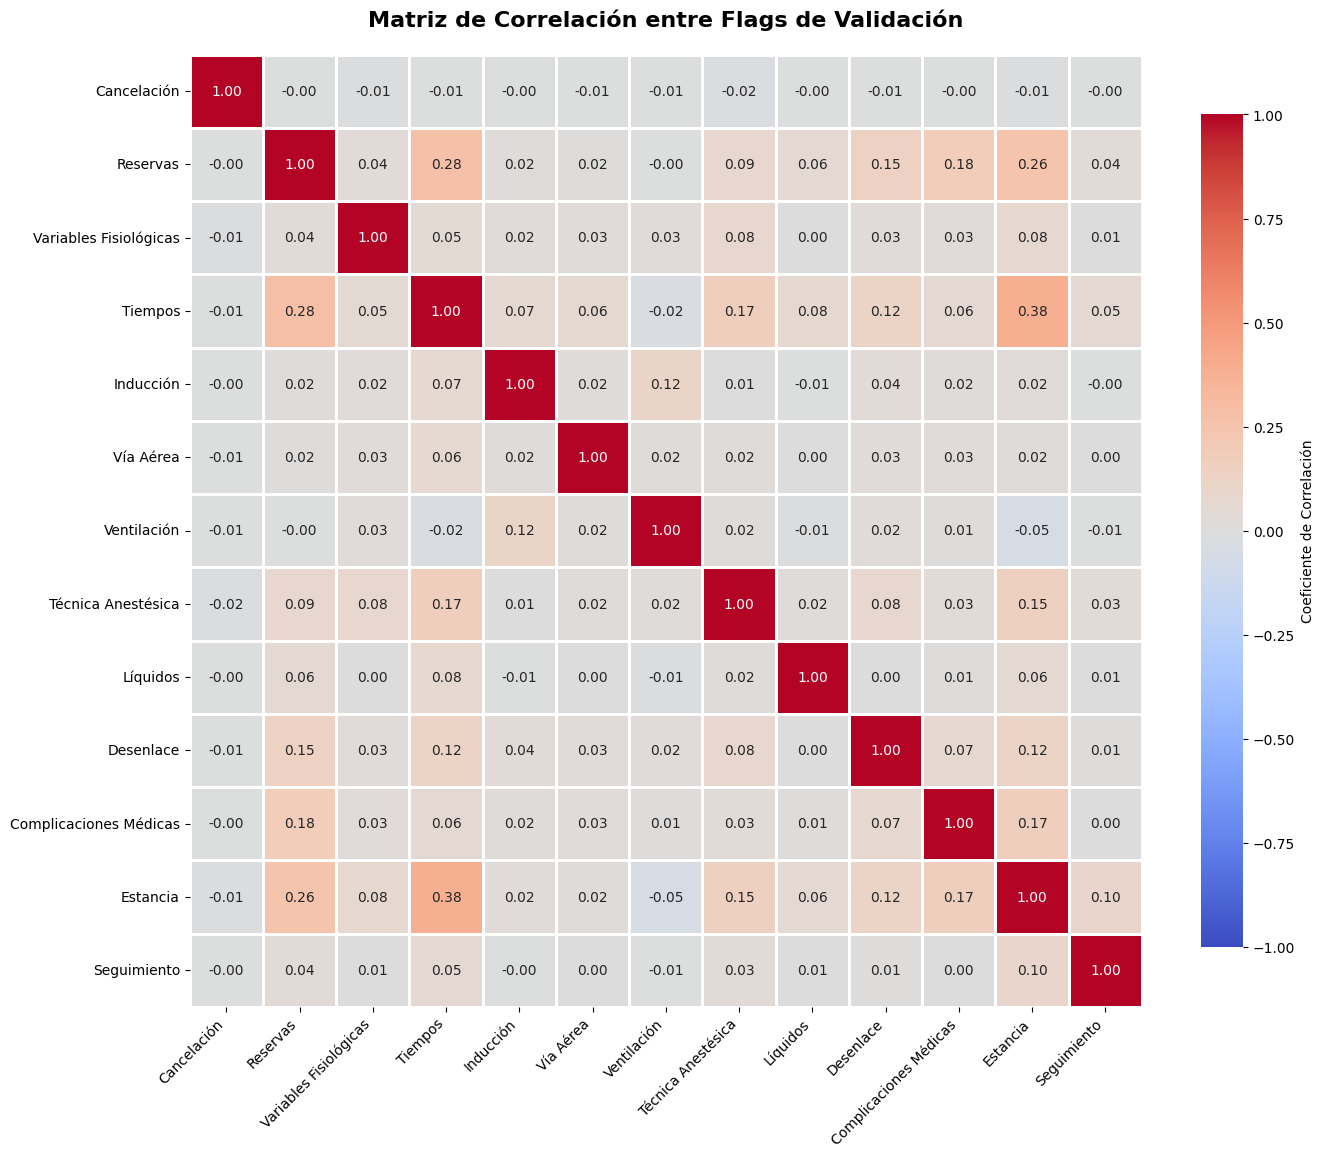


CORRELACIONES FUERTES ENTRE FLAGS
       Flag 1       Flag 2  Correlación     Tipo Fuerza
flag_estancia flag_tiempos     0.384932 Positiva  Débil
✓ Gráfico guardado en: ../../correlacion_flags_custom.png


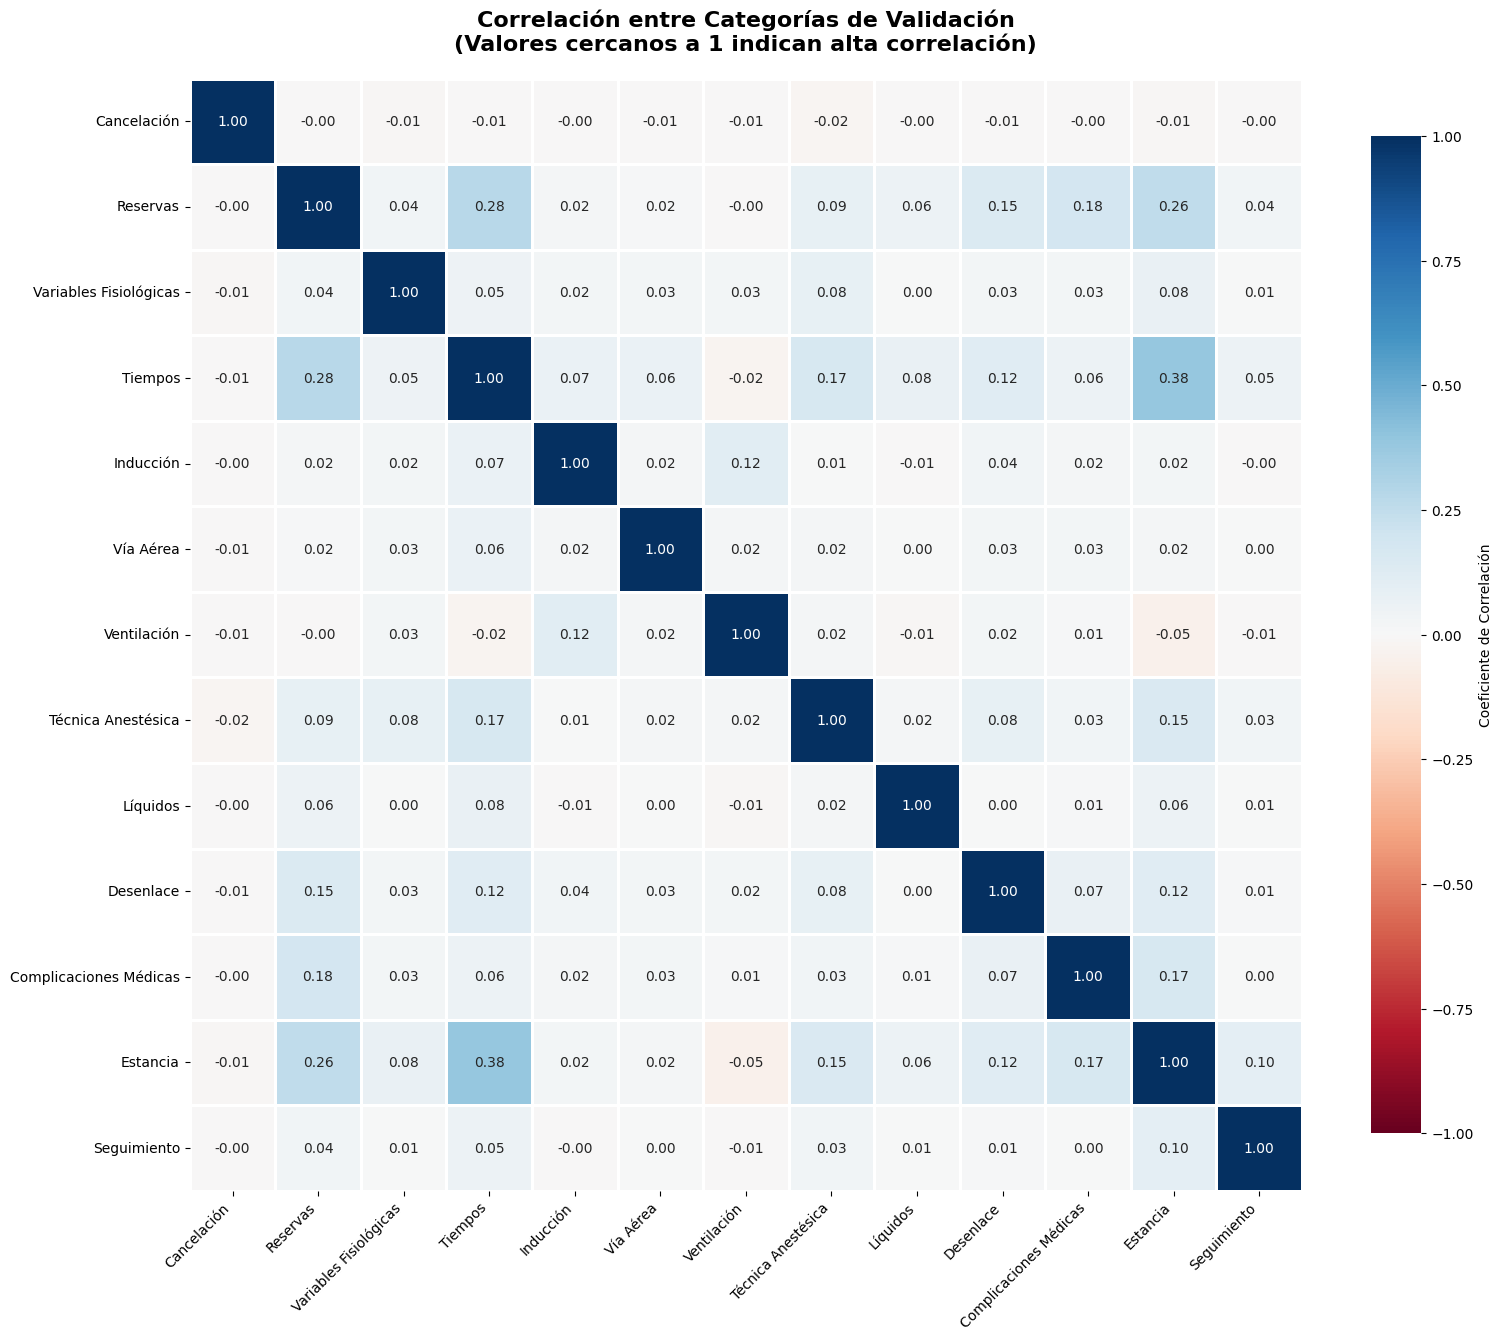

In [16]:
# Después de ejecutar el pipeline y tener el DataFrame con todos los flags

# 1. Generar heatmap básico
corr_matrix = plot_correlation_heatmap_flags(
    df=df,  # DataFrame con todos los flags calculados
    save_path='../../correlacion_flags.png'
)

# 2. Identificar correlaciones fuertes
correlaciones_fuertes = identificar_correlaciones_fuertes(
    corr_matrix=corr_matrix,
    umbral=0.3  # Correlación absoluta >= 0.3
)

print("\n" + "=" * 80)
print("CORRELACIONES FUERTES ENTRE FLAGS")
print("=" * 80)
print(correlaciones_fuertes.to_string(index=False))

# 3. Versión personalizada con colores diferentes
corr_matrix_custom = plot_correlation_heatmap_flags(
    df=df,
    cmap='RdBu',  # Rojo-Azul para mejor contraste
    figsize=(16, 14),
    title='Correlación entre Categorías de Validación\n(Valores cercanos a 1 indican alta correlación)',
    save_path='../../correlacion_flags_custom.png'
)

In [17]:

resumen = crear_tabla_resumen_ejecutiva(df)

KeyError: 'target'

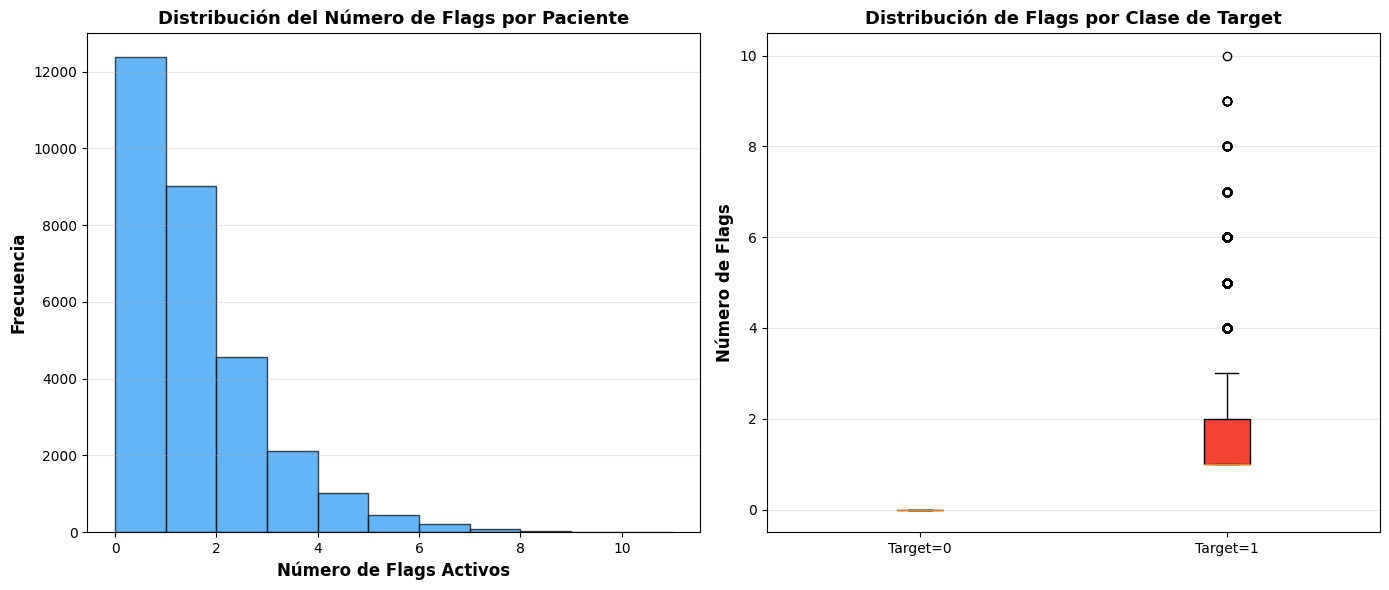


Estadísticas del número de flags:
  Media: 1.10
  Mediana: 1.00
  Máximo: 10

Por clase de target:
        count  unique  top   freq
target                           
0       12390       1    0  12390
1       17475      10    1   9009


In [ ]:
plot_distribucion_numero_flags(df)

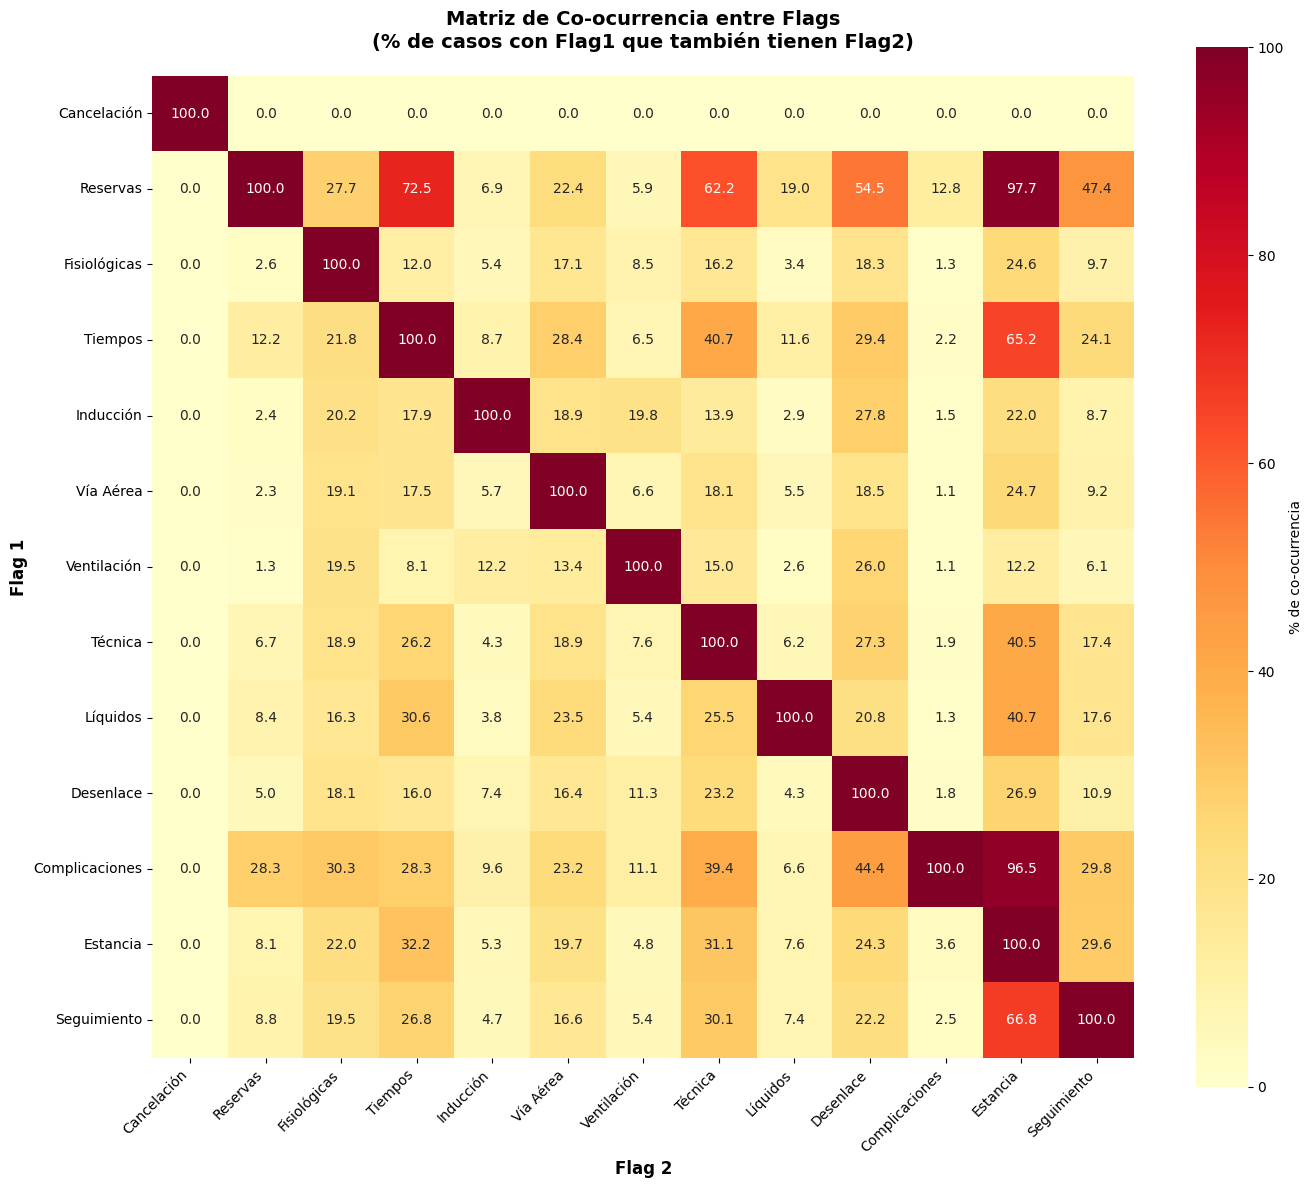

In [ ]:
plot_coocurrencia_flags(df)